In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
DATA_PATH_WEEKLY = "expenditure_weekly_clean.csv"      
DATA_CLEAN_DAILY = "expenditure_daily_stepwise.csv"

In [3]:
df_weekly = pd.read_csv(DATA_PATH_WEEKLY)

print("shape:", df_weekly.shape)
print(df_weekly.head(5))


shape: (636, 9)
       kategori_makanan  tahun  week_start    week_end  \
0  Bumbu-bumbuan/Spices   2024  01/01/2024  07/01/2024   
1  Bumbu-bumbuan/Spices   2024  08/01/2024  14/01/2024   
2  Bumbu-bumbuan/Spices   2024  15/01/2024  21/01/2024   
3  Bumbu-bumbuan/Spices   2024  22/01/2024  28/01/2024   
4  Bumbu-bumbuan/Spices   2024  29/01/2024  04/02/2024   

   ratarata_pengeluaran_per_kapita      iqr_low    iqr_high  \
0                       3941.57377  3416.365918  4816.92019   
1                       3941.57377  3416.365918  4816.92019   
2                       3941.57377  3416.365918  4816.92019   
3                       3941.57377  3416.365918  4816.92019   
4                       3941.57377  3416.365918  4816.92019   

   expenditure_value  outlier_iqr  
0         3941.57377        False  
1         3941.57377        False  
2         3941.57377        False  
3         3941.57377        False  
4         3941.57377        False  


In [4]:
df_daily = pd.read_csv(DATA_CLEAN_DAILY)

print("shape:", df_daily.shape)
print(df_daily.head(5))

shape: (4452, 8)
       kategori_makanan  tahun        date  ratarata_pengeluaran_per_kapita  \
0  Bumbu-bumbuan/Spices   2024  01/01/2024                       3941.57377   
1  Bumbu-bumbuan/Spices   2024  02/01/2024                       3941.57377   
2  Bumbu-bumbuan/Spices   2024  03/01/2024                       3941.57377   
3  Bumbu-bumbuan/Spices   2024  04/01/2024                       3941.57377   
4  Bumbu-bumbuan/Spices   2024  05/01/2024                       3941.57377   

       iqr_low    iqr_high  expenditure_value  outlier_iqr  
0  3416.365918  4816.92019         3941.57377        False  
1  3416.365918  4816.92019         3941.57377        False  
2  3416.365918  4816.92019         3941.57377        False  
3  3416.365918  4816.92019         3941.57377        False  
4  3416.365918  4816.92019         3941.57377        False  


In [5]:
print("\n--- INFO ---")
print(df_weekly.info())

print("\n--- DUPLICATES (rows) ---")
print("duplicate rows:", df_weekly.duplicated().sum())

print("\n--- MISSING (per column) ---")
missing = df_weekly.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_weekly) * 100).round(2)
print(pd.DataFrame({"missing": missing, "missing_%": missing_pct}).head(30))

print("\n--- BASIC STATS (numeric) ---")
print(df_weekly.describe())


--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kategori_makanan                 636 non-null    object 
 1   tahun                            636 non-null    int64  
 2   week_start                       636 non-null    object 
 3   week_end                         636 non-null    object 
 4   ratarata_pengeluaran_per_kapita  636 non-null    float64
 5   iqr_low                          636 non-null    float64
 6   iqr_high                         636 non-null    float64
 7   expenditure_value                636 non-null    float64
 8   outlier_iqr                      636 non-null    bool   
dtypes: bool(1), float64(4), int64(1), object(3)
memory usage: 40.5+ KB
None

--- DUPLICATES (rows) ---
duplicate rows: 0

--- MISSING (per column) ---
                                 missing  missin

In [15]:
df_weekly["tahun"] = pd.PeriodIndex(df_weekly["tahun"], freq="Y")

In [7]:
df_weekly["week_start"] = pd.to_datetime(df_weekly["week_start"], format="%d/%m/%Y", errors="coerce")
df_weekly["week_end"] = pd.to_datetime(df_weekly["week_end"], format="%d/%m/%Y", errors="coerce")

In [8]:
print(df_weekly["week_start"].dtype)
print(df_weekly["week_end"].dtype)
print(df_weekly["week_start"].isna().sum())
print(df_weekly.loc[df_weekly["week_start"].isna(), "week_start"].head())
print(df_weekly["week_end"].isna().sum())
print(df_weekly.loc[df_weekly["week_end"].isna(), "week_end"].head())

datetime64[ns]
datetime64[ns]
0
Series([], Name: week_start, dtype: datetime64[ns])
0
Series([], Name: week_end, dtype: datetime64[ns])


In [9]:
print("\n--- INFO ---")
print(df_daily.info())

print("\n--- DUPLICATES (rows) ---")
print("duplicate rows:", df_daily.duplicated().sum())

print("\n--- MISSING (per column) ---")
missing = df_daily.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_daily) * 100).round(2)
print(pd.DataFrame({"missing": missing, "missing_%": missing_pct}).head(30))

print("\n--- BASIC STATS (numeric) ---")
print(df_daily.describe())


--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4452 entries, 0 to 4451
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   kategori_makanan                 4452 non-null   object 
 1   tahun                            4452 non-null   int64  
 2   date                             4452 non-null   object 
 3   ratarata_pengeluaran_per_kapita  4452 non-null   float64
 4   iqr_low                          4452 non-null   float64
 5   iqr_high                         4452 non-null   float64
 6   expenditure_value                4452 non-null   float64
 7   outlier_iqr                      4452 non-null   bool   
dtypes: bool(1), float64(4), int64(1), object(2)
memory usage: 247.9+ KB
None

--- DUPLICATES (rows) ---
duplicate rows: 0

--- MISSING (per column) ---
                                 missing  missing_%
kategori_makanan                       0        0.0
tah

In [16]:
df_daily["tahun"] = pd.PeriodIndex(df_daily["tahun"], freq="Y")

In [10]:
df_daily["date"] = pd.to_datetime(df_daily["date"], format="%d/%m/%Y", errors="coerce")

In [17]:
print(df_daily["date"].dtype)
print(df_daily["date"].isna().sum())
print(df_daily.loc[df_daily["date"].isna(), "date"].head())

datetime64[ns]
0
Series([], Name: date, dtype: datetime64[ns])


In [37]:
cat_cols_weekly = df_weekly.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols_weekly = df_weekly.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_weekly_cols_weekly = [c for c in num_cols_weekly if c != "Jumlah makanan/Total food"]

print("\ncat_cols:", cat_cols_weekly)
print("num_cols:", num_cols_weekly)



cat_cols: ['kategori_makanan']
num_cols: ['ratarata_pengeluaran_per_kapita', 'iqr_low', 'iqr_high', 'expenditure_value']


In [19]:
date_cols_weekly = df_weekly.select_dtypes(include=["datetime64[ns]"]).columns.tolist()
print("date_cols:", date_cols_weekly)

date_cols: ['week_start', 'week_end']


In [38]:
cat_cols_daily = df_daily.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols_daily = df_daily.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_daily = [c for c in num_cols_daily if c != "Jumlah makanan/Total food"]

print("\ncat_cols:", cat_cols_daily)
print("num_cols:", num_cols_daily)


cat_cols: ['ratarata_pengeluaran_per_kapita', 'iqr_low', 'iqr_high', 'expenditure_value']
num_cols: ['ratarata_pengeluaran_per_kapita', 'iqr_low', 'iqr_high', 'expenditure_value']


In [21]:
date_cols_daily = df_daily.select_dtypes(include=["datetime64[ns]"]).columns.tolist()
print("date_cols:", date_cols_daily)

date_cols: ['date']


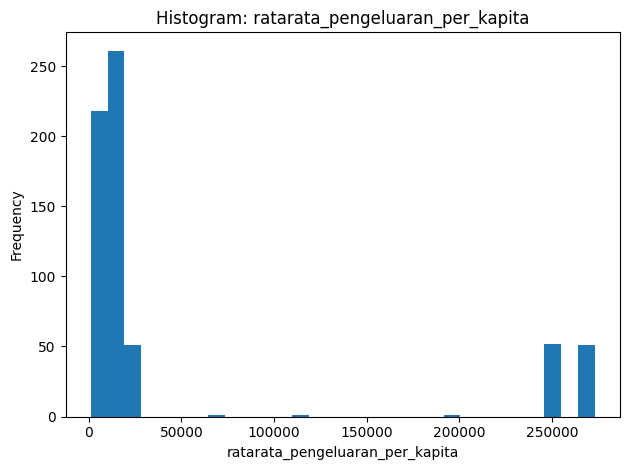

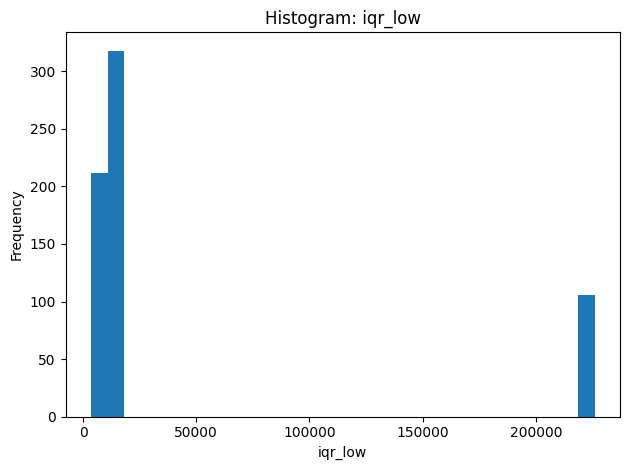

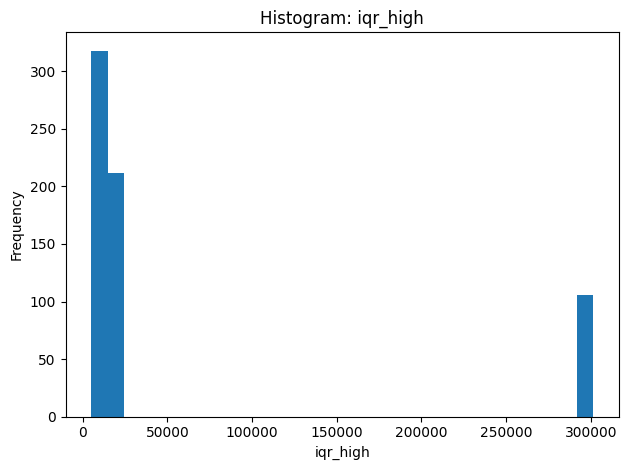

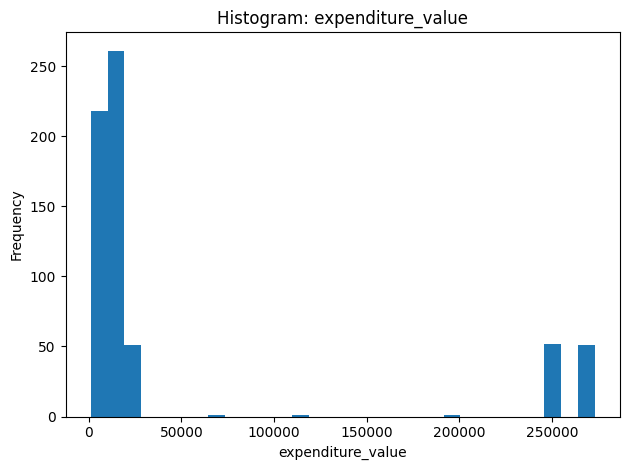

In [39]:
for c in num_cols_weekly[:10]:
    df_weekly[c].plot(kind="hist", bins=30, title=f"Histogram: {c}")
    plt.xlabel(c)
    plt.tight_layout()
    plt.show()

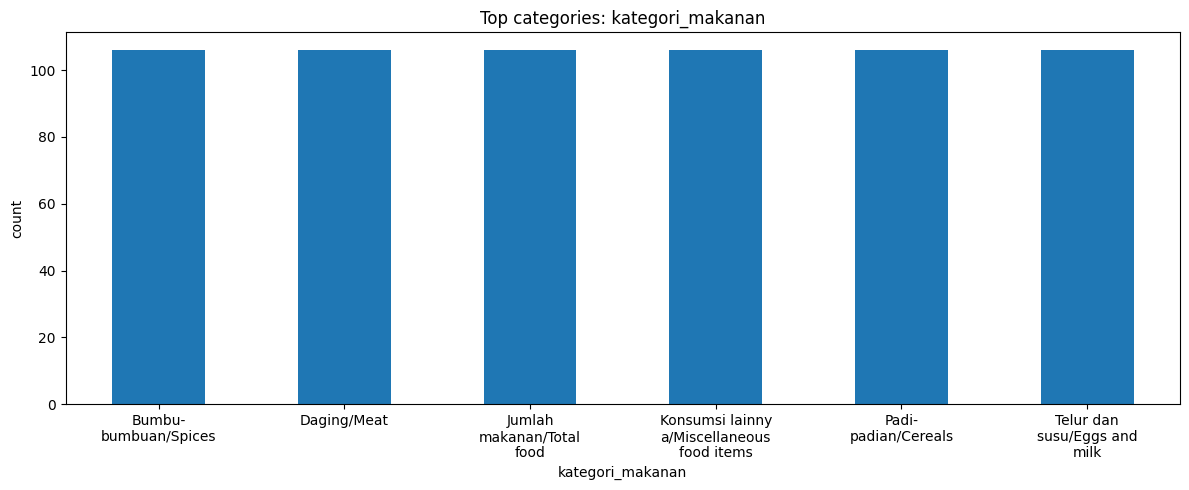

In [33]:
import textwrap

for c in cat_cols_weekly[:5]:
    vc = df_weekly[c].value_counts(dropna=False).head(10)

    ax = vc.plot(kind="bar", figsize=(12, 5), title=f"Top categories: {c}")
    ax.set_ylabel("count")

    labels = [textwrap.fill(str(t.get_text()), width=15) for t in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=0)  

    plt.tight_layout()
    plt.show()

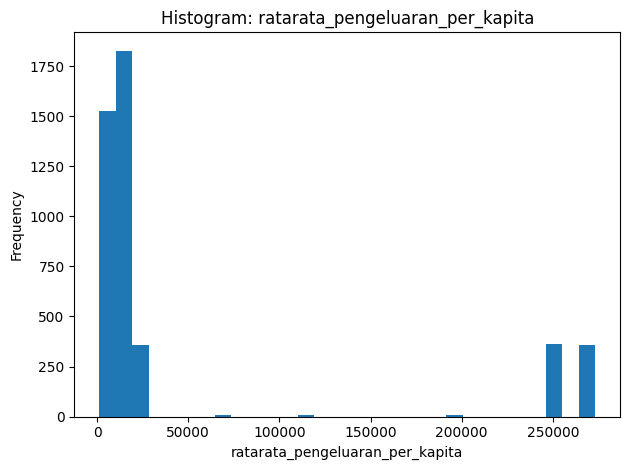

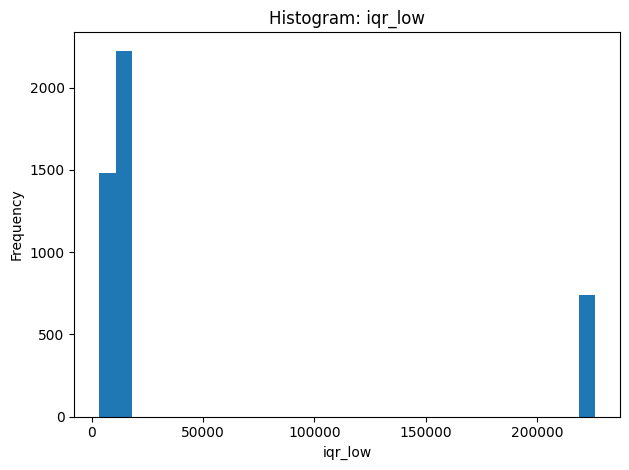

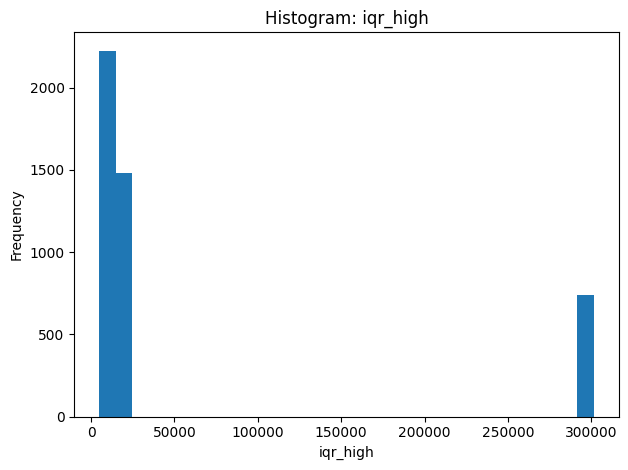

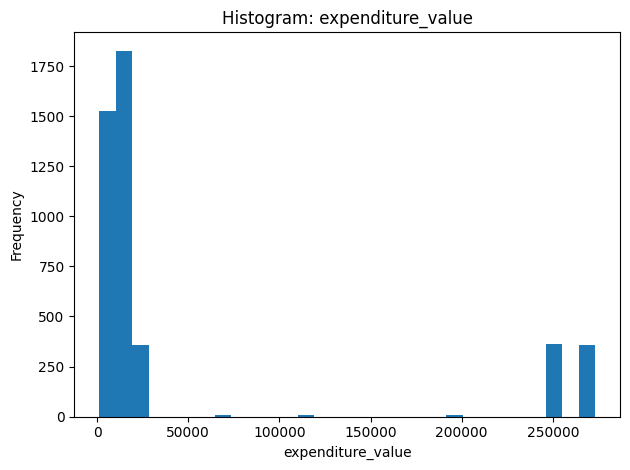

In [34]:
for c in num_cols_daily[:10]:
    df_daily[c].plot(kind="hist", bins=30, title=f"Histogram: {c}")
    plt.xlabel(c)
    plt.tight_layout()
    plt.show()

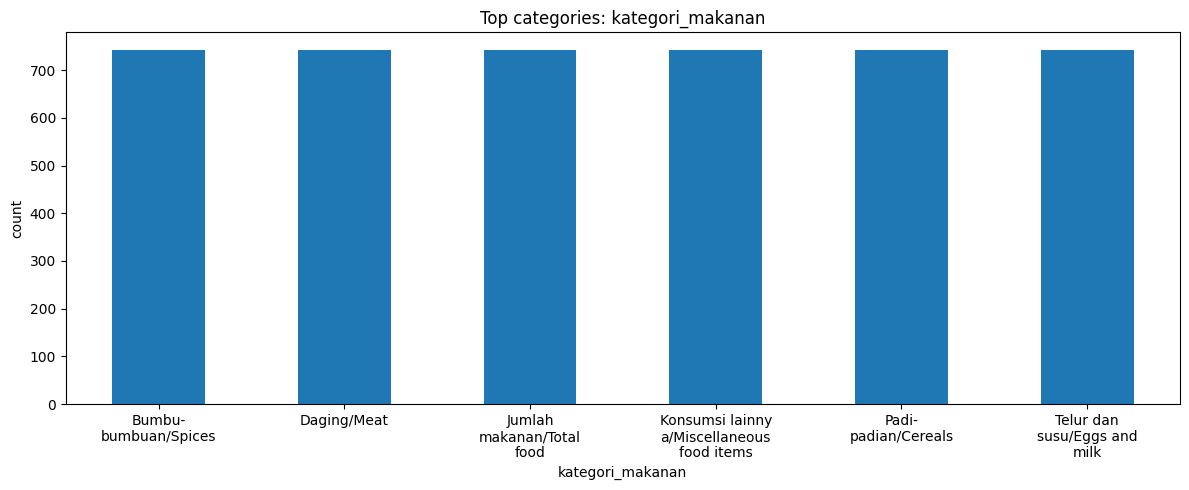

In [35]:
for c in cat_cols_daily[:5]:
    vc = df_daily[c].value_counts(dropna=False).head(10)

    ax = vc.plot(kind="bar", figsize=(12, 5), title=f"Top categories: {c}")
    ax.set_ylabel("count")

    labels = [textwrap.fill(str(t.get_text()), width=15) for t in ax.get_xticklabels()]
    ax.set_xticklabels(labels, rotation=0)  

    plt.tight_layout()
    plt.show()

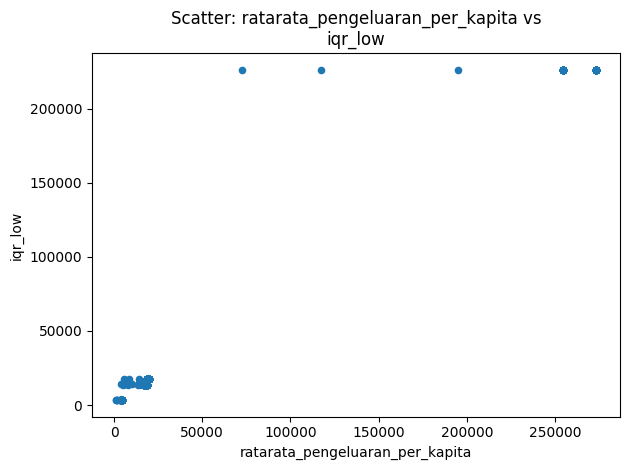

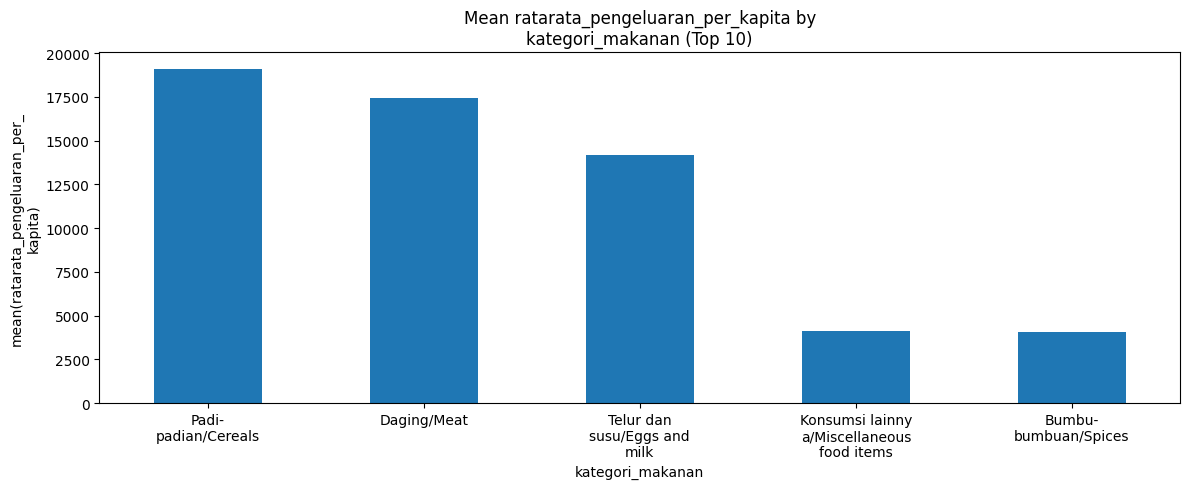

In [42]:
def wrap(s, width=40):
    return "\n".join(textwrap.wrap(str(s), width=width))

if len(num_cols_weekly) >= 2:
    x, y = num_cols_weekly[0], num_cols_weekly[1]
    ax = df_weekly.plot(kind="scatter", x=x, y=y)
    ax.set_title(wrap(f"Scatter: {x} vs {y}", 50))
    plt.tight_layout()
    plt.show()

if cat_cols_weekly and num_cols_weekly:
    c = cat_cols_weekly[0]
    n = num_cols_weekly[0]

    EXCLUDE_CAT = "Jumlah makanan/Total food"  

    df2 = df_weekly[
        df_weekly[c].astype(str).str.strip().str.lower()
        != EXCLUDE_CAT.strip().lower()
    ]
    grp = df2.groupby(c)[n].mean().sort_values(ascending=False).head(10)

    ax = grp.plot(kind="bar", figsize=(12, 5))
    ax.set_title(wrap(f"Mean {n} by {c} (Top 10)", 50))
    ax.set_ylabel(wrap(f"mean({n})", 30))

    xt = [wrap(t.get_text(), 15) for t in ax.get_xticklabels()]
    ax.set_xticklabels(xt, rotation=0)

    plt.tight_layout()
    plt.show()


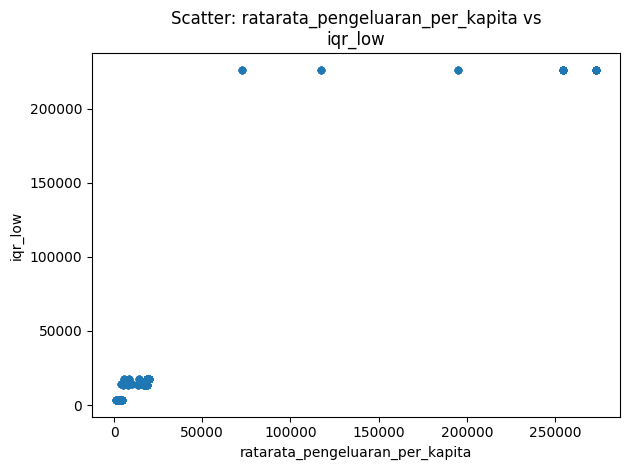

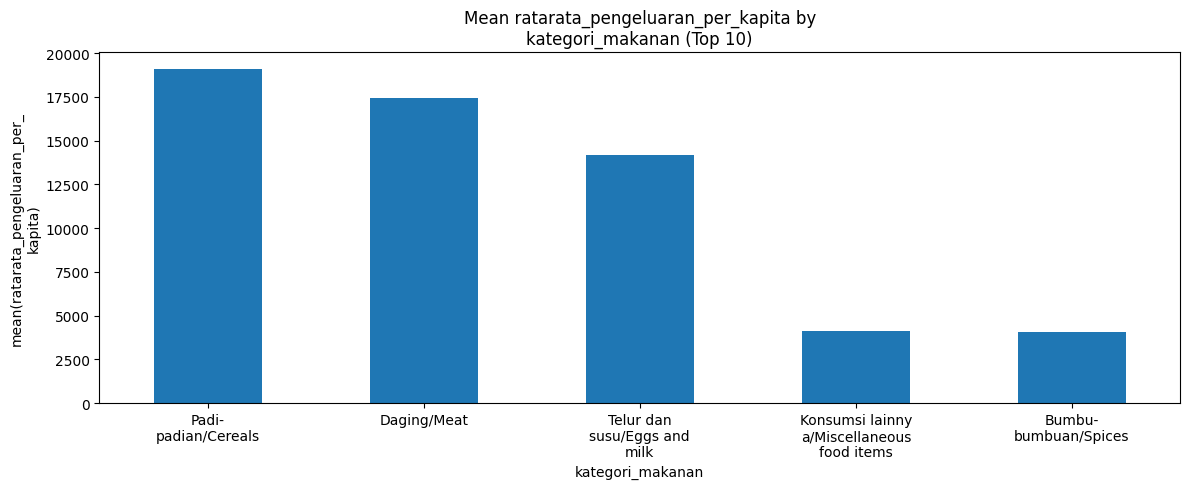

In [45]:
def wrap(s, width=40):
    return "\n".join(textwrap.wrap(str(s), width=width))


if len(num_cols_daily) >= 2:
    x, y = num_cols_daily[0], num_cols_daily[1]
    ax = df_daily.plot(kind="scatter", x=x, y=y)
    ax.set_title(wrap(f"Scatter: {x} vs {y}", 50))
    plt.tight_layout()
    plt.show()
    
c = "kategori_makanan"                
n = "ratarata_pengeluaran_per_kapita"  

EXCLUDE_CAT = "Jumlah makanan/Total food"

df2 = df_daily[
    df_daily[c].astype(str).str.strip().str.lower()
    != EXCLUDE_CAT.strip().lower()
]

grp = df2.groupby(c)[n].mean().sort_values(ascending=False).head(10)

ax = grp.plot(kind="bar", figsize=(12, 5))
ax.set_title(wrap(f"Mean {n} by {c} (Top 10)", 50))
ax.set_ylabel(wrap(f"mean({n})", 30))

xt = [wrap(t.get_text(), 15) for t in ax.get_xticklabels()]
ax.set_xticklabels(xt, rotation=0)

plt.tight_layout()
plt.show()

In [51]:
WS = "week_start"  
WE = "week_end"     
VAL = "ratarata_pengeluaran_per_kapita" 
CAT = "kategori_makanan"  

EXCLUDE_CAT = "Jumlah makanan/Total food"

dfw = df_weekly.copy()

# 1) parse date + sort
dfw[WS] = pd.to_datetime(dfw[WS], errors="coerce")
dfw[WE] = pd.to_datetime(dfw[WE], errors="coerce")
dfw = dfw.dropna(subset=[WS]).sort_values(WS)

print("dtype:", dfw[WS].dtype, dfw[WE].dtype)
print("range:", dfw[WS].min(), "->", dfw[WS].max())

# 2) cek durasi minggu 
dfw["week_len_days"] = (dfw[WE] - dfw[WS]).dt.days
print(dfw["week_len_days"].value_counts(dropna=False).head(10))

# 3) cek gap antar minggu 
dfw["gap_days"] = dfw[WS].diff().dt.days
print(dfw["gap_days"].value_counts(dropna=False).head(10))

dtype: datetime64[ns] datetime64[ns]
range: 2024-01-01 00:00:00 -> 2025-12-29 00:00:00
week_len_days
6    636
Name: count, dtype: int64
gap_days
0.0    531
7.0    104
NaN      1
Name: count, dtype: int64


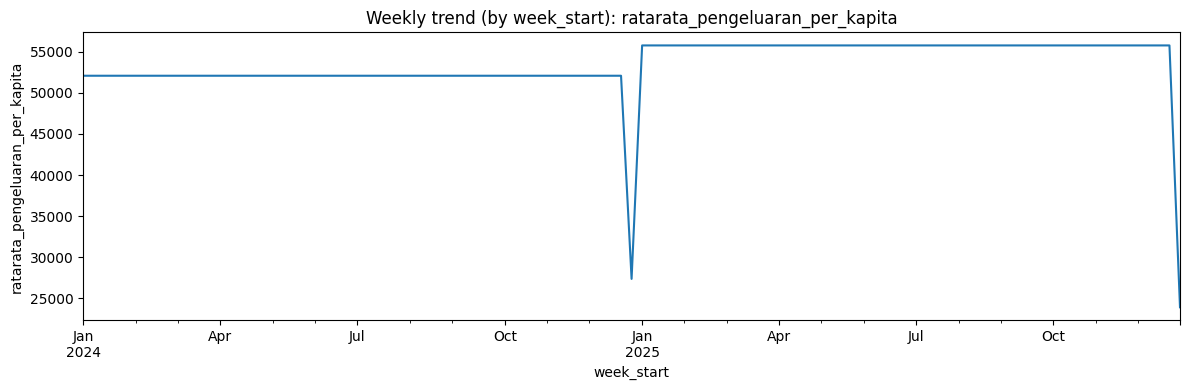

In [47]:
ts = dfw.groupby(WS)[VAL].mean()   # atau .sum() kalau metriknya jumlah
ax = ts.plot(figsize=(12,4), title=f"Weekly trend (by {WS}): {VAL}")
ax.set_xlabel("week_start")
ax.set_ylabel(VAL)
plt.tight_layout()
plt.show()

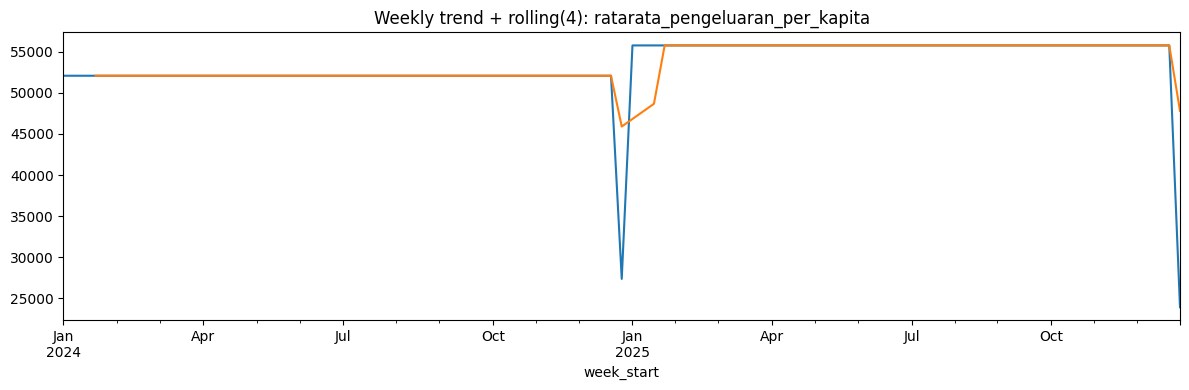

In [48]:
ts = dfw.groupby(WS)[VAL].mean()
roll = ts.rolling(4).mean()

ax = ts.plot(figsize=(12,4), title=f"Weekly trend + rolling(4): {VAL}")
roll.plot(ax=ax)
plt.tight_layout()
plt.show()

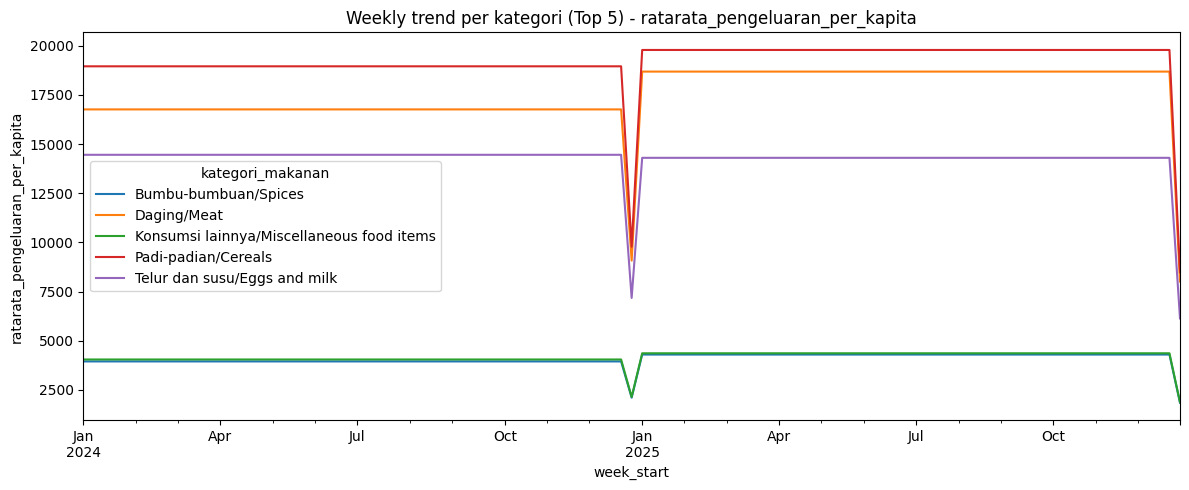

In [53]:
dfw2 = dfw[
    dfw[CAT].astype(str).str.strip().str.lower()
    != EXCLUDE_CAT.strip().lower()
]

top = dfw2.groupby(CAT)[VAL].mean().sort_values(ascending=False).head(5).index

df_top = dfw2[dfw2[CAT].isin(top)]

pivot = (
    df_top.groupby([WS, CAT])[VAL].mean()
    .unstack(CAT)
    .sort_index()
)

ax = pivot.plot(figsize=(12,5), title=f"Weekly trend per kategori (Top 5) - {VAL}")
ax.set_xlabel("week_start")
ax.set_ylabel(VAL)
plt.tight_layout()
plt.show()

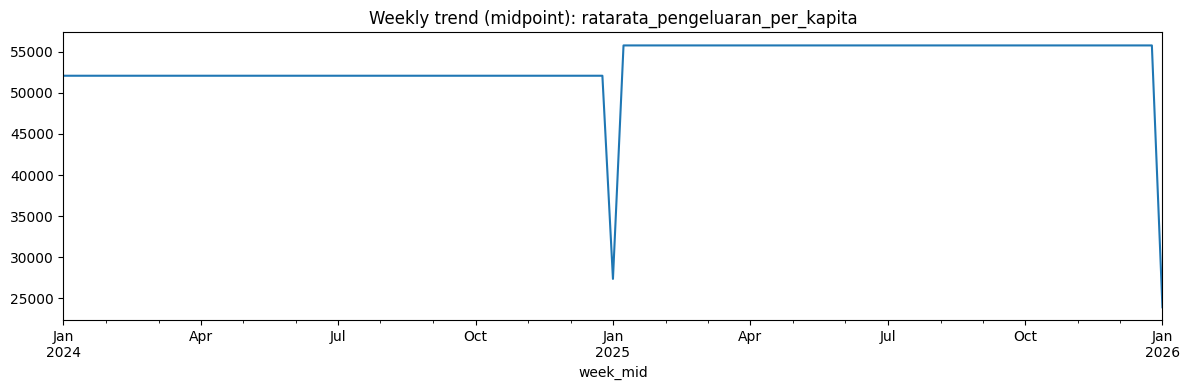

In [54]:
dfw["week_mid"] = dfw[WS] + (dfw[WE] - dfw[WS]) / 2
ts = dfw.groupby("week_mid")[VAL].mean()

ax = ts.plot(figsize=(12,4), title=f"Weekly trend (midpoint): {VAL}")
plt.tight_layout()
plt.show()

In [55]:
DATE_COL_DAILY = "date"   
VALUE_COL_DAILY = "ratarata_pengeluaran_per_kapita" 
CAT_COL_DAILY = "kategori_makanan" 

EXCLUDE_CAT = "Jumlah makanan/Total food"

df = df_daily.copy()
df[DATE_COL_DAILY] = pd.to_datetime(df[DATE_COL_DAILY], errors="coerce")
df = df.dropna(subset=[DATE_COL_DAILY]).sort_values(DATE_COL_DAILY)

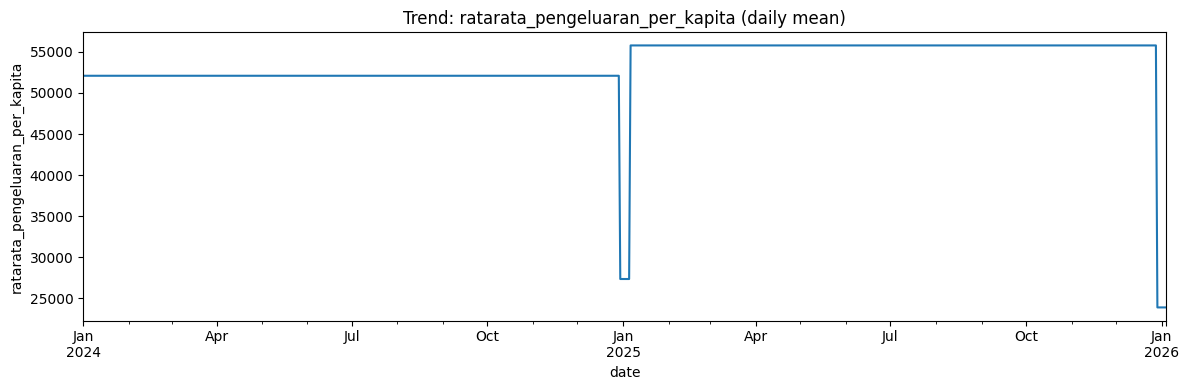

In [56]:
ts = df.groupby(DATE_COL_DAILY)[VALUE_COL_DAILY].mean()

ax = ts.plot(figsize=(12,4), title=f"Trend: {VALUE_COL_DAILY} (daily mean)")
ax.set_xlabel("date")
ax.set_ylabel(VALUE_COL_DAILY)
plt.tight_layout()
plt.show()

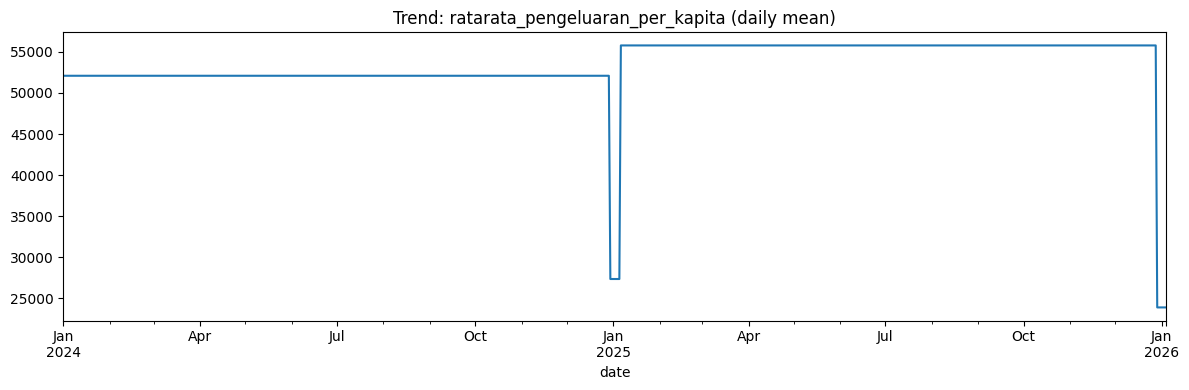

In [ ]:
ts = df.set_index(DATE_COL_DAILY)[VALUE_COL_DAILY].resample("D").mean()
ax = ts.plot(figsize=(12,4), title=f"Trend: {VALUE_COL_DAILY} (daily mean)")
plt.tight_layout()
plt.show()

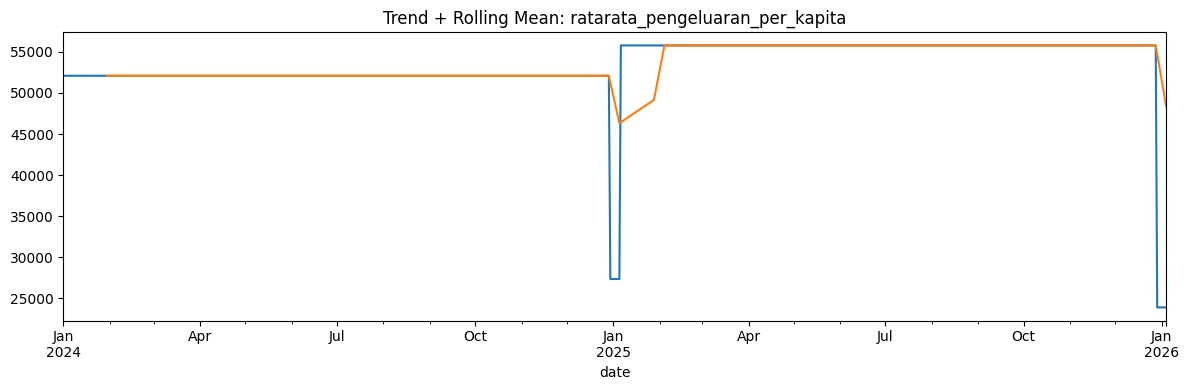

In [59]:
ts = df.set_index(DATE_COL_DAILY)[VALUE_COL_DAILY].resample("D").mean()
roll = ts.rolling(30).mean()  

ax = ts.plot(figsize=(12,4), title=f"Trend + Rolling Mean: {VALUE_COL_DAILY}")
roll.plot(ax=ax) 
plt.tight_layout()
plt.show()

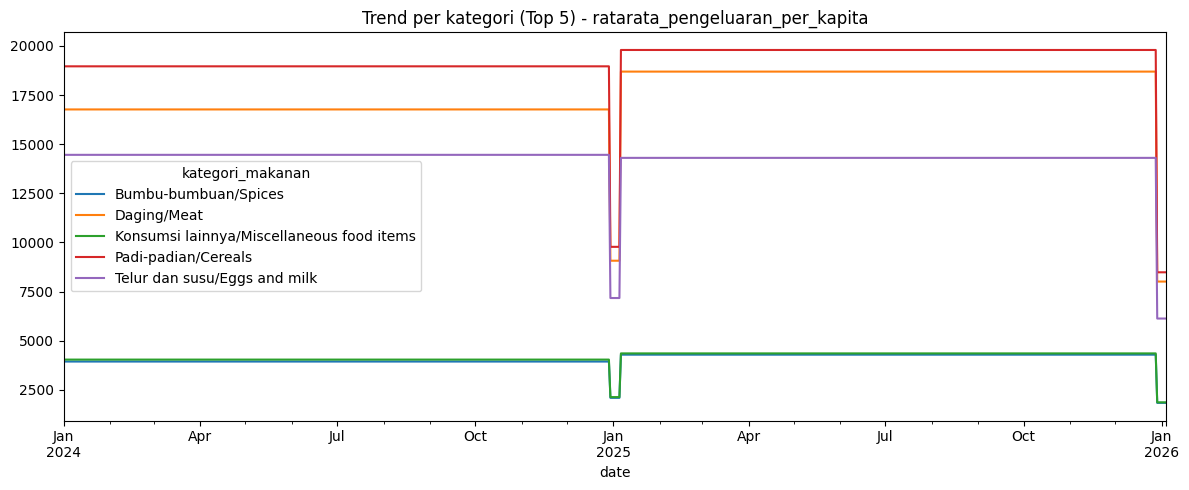

In [61]:
dfd2 = df[
    df[CAT_COL_DAILY].astype(str).str.strip().str.lower()
    != EXCLUDE_CAT.strip().lower()
]


top = dfd2.groupby(CAT_COL_DAILY)[VALUE_COL_DAILY].mean().sort_values(ascending=False).head(5).index

df_top = df[df[CAT_COL_DAILY].isin(top)]
pivot = (
    df_top.groupby([DATE_COL_DAILY, CAT_COL_DAILY])[VALUE_COL_DAILY].mean()
    .unstack(CAT_COL_DAILY)
    .sort_index()
)

ax = pivot.plot(figsize=(12,5), title=f"Trend per kategori (Top 5) - {VALUE_COL_DAILY}")
plt.tight_layout()
plt.show()

In [62]:
d = df[DATE_COL_DAILY].dropna().sort_values()
gaps = d.diff().value_counts().head(10)
print(gaps)

date
0 days    3717
1 days     734
Name: count, dtype: int64


In [63]:
full = pd.date_range(d.min(), d.max(), freq="D")
missing = full.difference(d.unique())
print("missing days:", len(missing))
print(missing[:20])

missing days: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='D')


In [66]:
def dist_profile(df, num_cols=None, topn=10):
    if num_cols is None:
        num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    else:
        num_cols = num_cols
    rows = []
    for c in num_cols:
        s = pd.to_numeric(df[c], errors="coerce").dropna()
        if s.empty:
            continue

        q = s.quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
        rows.append({
            "col": c,
            "n": int(s.size),
            "missing": int(df[c].isna().sum()),
            "mean": float(s.mean()),
            "std": float(s.std()),
            "min": float(s.min()),
            "p01": float(q.loc[0.01]),
            "p05": float(q.loc[0.05]),
            "p25": float(q.loc[0.25]),
            "p50": float(q.loc[0.50]),
            "p75": float(q.loc[0.75]),
            "p95": float(q.loc[0.95]),
            "p99": float(q.loc[0.99]),
            "max": float(s.max()),
            "skew": float(s.skew()),
            "kurt": float(s.kurt())
        })

    prof = pd.DataFrame(rows).sort_values("skew", key=lambda x: x.abs(), ascending=False)
    print(prof.head(topn))
    return prof

def plot_univariate(df, col, bins=30):
    s = pd.to_numeric(df[col], errors="coerce")
    fig, ax = plt.subplots(figsize=(10,4))
    s.plot(kind="hist", bins=bins, ax=ax, title=f"Histogram: {col}")
    ax.set_xlabel(col)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(6,4))
    df[[col]].plot(kind="box", ax=ax, title=f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()

def plot_box_by_category(df, value_col, cat_col, topk=10):
    # ambil top kategori biar gak kebanyakan
    top = df[cat_col].value_counts(dropna=False).head(topk).index
    d = df[df[cat_col].isin(top)].copy()

    # list-of-arrays untuk boxplot
    groups = []
    labels = []
    for k in top:
        s = pd.to_numeric(d.loc[d[cat_col] == k, value_col], errors="coerce").dropna()
        if not s.empty:
            groups.append(s.values)
            labels.append(str(k))

    plt.figure(figsize=(12,5))
    plt.boxplot(groups, labels=labels, showfliers=True)  
    plt.xticks(rotation=45, ha="right")
    plt.title(f"{value_col} by {cat_col} (Top {topk})")
    plt.tight_layout()
    plt.show()

In [67]:
prof_weekly = dist_profile(df_weekly)

                               col    n  missing          mean            std  \
0  ratarata_pengeluaran_per_kapita  636        0  53128.308055   93317.497679   
3                expenditure_value  636        0  53128.308055   93317.497679   
2                         iqr_high  636        0  61412.340335  107678.088525   
1                          iqr_low  636        0  46448.259960   80560.789465   

           min          p01          p05          p25          p50  \
0  1126.163934  3941.573770  3941.573770  4291.712338  14456.72131   
3  1126.163934  3941.573770  3941.573770  4291.712338  14456.72131   
2  4816.920190  4816.920190  4816.920190  4828.706568  17863.17536   
1  3416.365918  3416.365918  3416.365918  3568.297372  13975.36924   

           p75          p95          p99          max      skew      kurt  
0  18959.67213  273217.8236  273217.8236  273217.8236  1.808224  1.328047  
3  18959.67213  273217.8236  273217.8236  273217.8236  1.808224  1.328047  
2  21578.62023 

In [68]:
prof_weekly = dist_profile(df_weekly)

                               col    n  missing          mean            std  \
0  ratarata_pengeluaran_per_kapita  636        0  53128.308055   93317.497679   
3                expenditure_value  636        0  53128.308055   93317.497679   
2                         iqr_high  636        0  61412.340335  107678.088525   
1                          iqr_low  636        0  46448.259960   80560.789465   

           min          p01          p05          p25          p50  \
0  1126.163934  3941.573770  3941.573770  4291.712338  14456.72131   
3  1126.163934  3941.573770  3941.573770  4291.712338  14456.72131   
2  4816.920190  4816.920190  4816.920190  4828.706568  17863.17536   
1  3416.365918  3416.365918  3416.365918  3568.297372  13975.36924   

           p75          p95          p99          max      skew      kurt  
0  18959.67213  273217.8236  273217.8236  273217.8236  1.808224  1.328047  
3  18959.67213  273217.8236  273217.8236  273217.8236  1.808224  1.328047  
2  21578.62023 

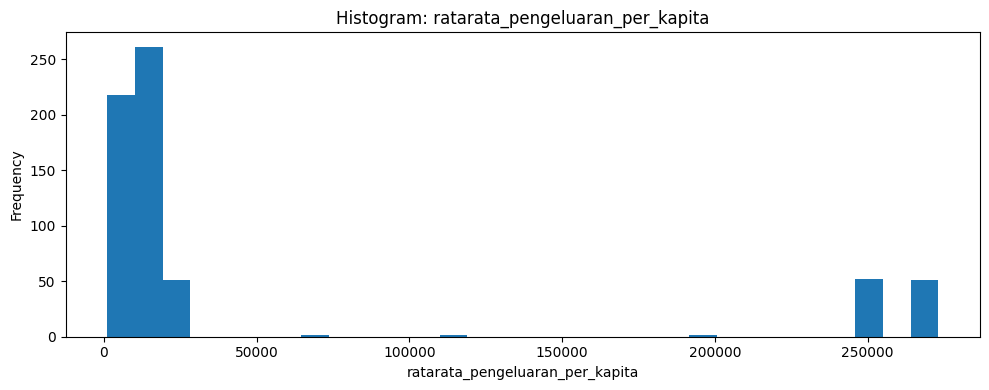

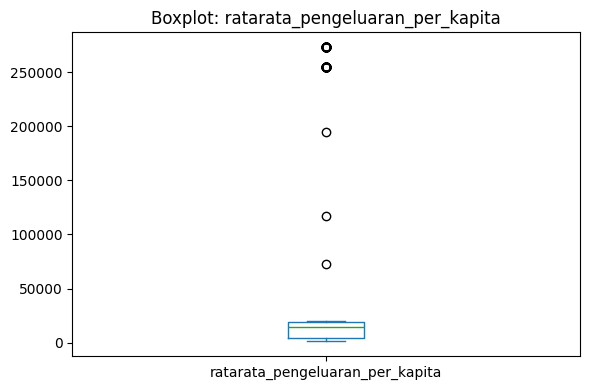

In [69]:
plot_univariate(df_weekly, "ratarata_pengeluaran_per_kapita")

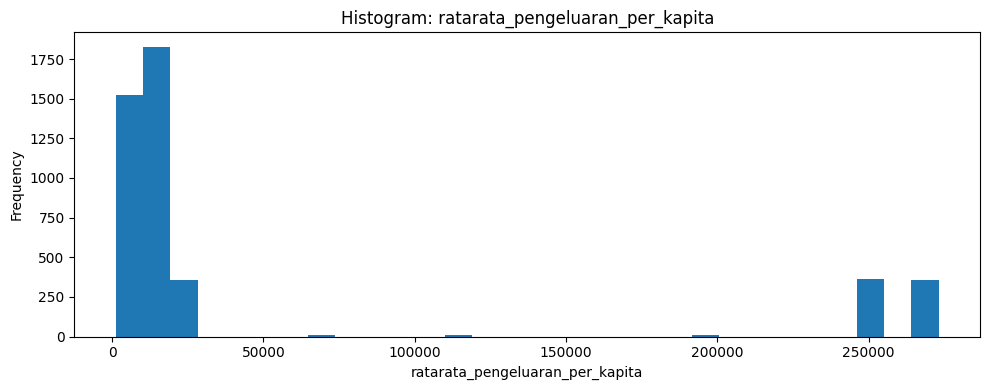

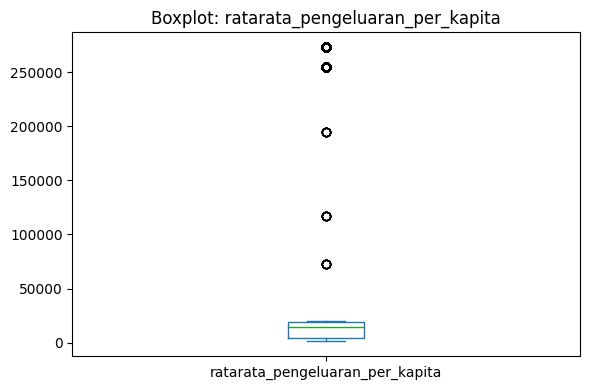

In [70]:
plot_univariate(df_daily, "ratarata_pengeluaran_per_kapita")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30120\2755655787.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


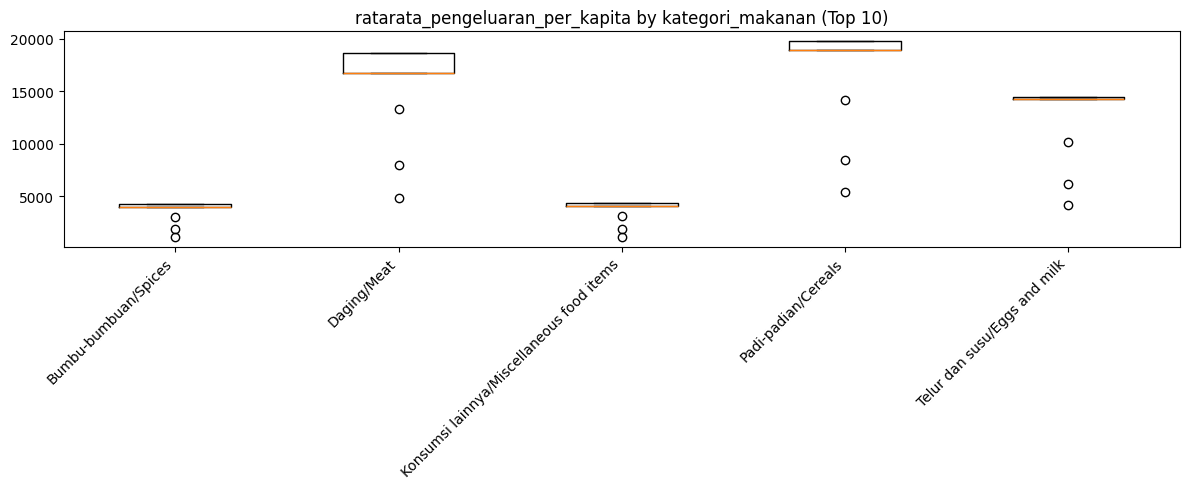

In [72]:
EXCLUDE_CAT = "Jumlah makanan/Total food"

dfw2 = df_weekly[
    df_weekly["kategori_makanan"].astype(str).str.strip().str.lower()
    != EXCLUDE_CAT.strip().lower()
]

plot_box_by_category(dfw2,
    value_col="ratarata_pengeluaran_per_kapita",
    cat_col="kategori_makanan",
    topk=10
)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_30120\2755655787.py:64: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=labels, showfliers=True)


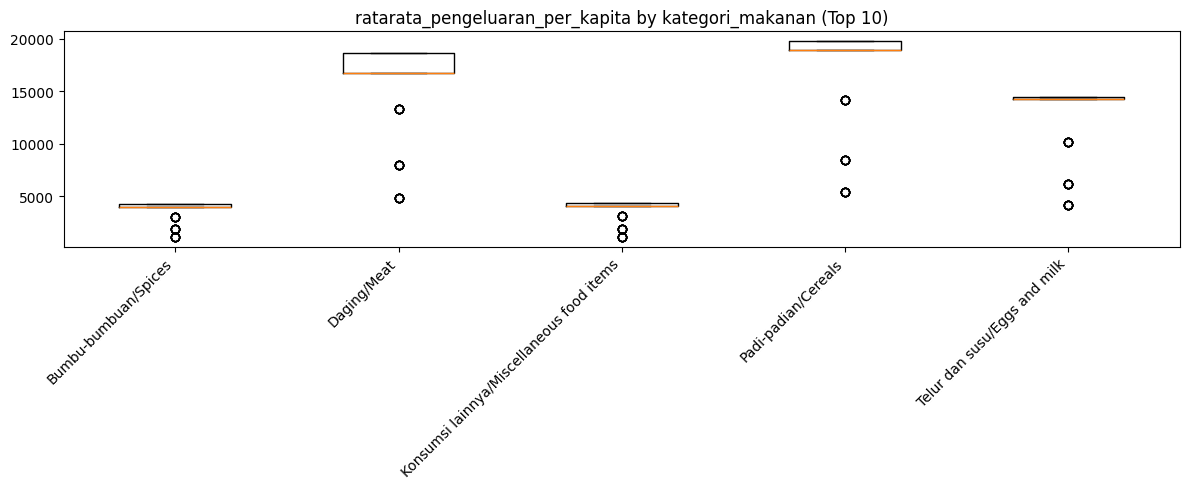

In [73]:
EXCLUDE_CAT = "Jumlah makanan/Total food"

dfw2 = df_daily[
    df_daily["kategori_makanan"].astype(str).str.strip().str.lower()
    != EXCLUDE_CAT.strip().lower()
]

plot_box_by_category(dfw2,
    value_col="ratarata_pengeluaran_per_kapita",
    cat_col="kategori_makanan",
    topk=10
)

In [74]:
def iqr_bounds(s: pd.Series, k: float = 1.5):
    s = pd.to_numeric(s, errors="coerce")
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    return lo, hi

def flag_outlier_iqr(s: pd.Series, k: float = 1.5) -> pd.Series:
    lo, hi = iqr_bounds(s, k=k)
    s = pd.to_numeric(s, errors="coerce")
    return (s < lo) | (s > hi)

In [75]:
dfw = df_weekly.copy()
dfw[WS] = pd.to_datetime(dfw[WS], errors="coerce")
dfw[WE] = pd.to_datetime(dfw[WE], errors="coerce")
dfw = dfw.dropna(subset=[WS]).sort_values(WS)

# optional: buang "Jumlah makanan/Total food"
if CAT in dfw.columns:
    dfw = dfw[
        dfw[CAT].astype(str).str.strip().str.lower()
        != EXCLUDE_CAT.strip().lower()
    ]

# flag outlier
mask = flag_outlier_iqr(dfw[VAL], k=1.5)
dfw["is_outlier"] = mask

lo, hi = iqr_bounds(dfw[VAL], k=1.5)
print("IQR bounds:", lo, "to", hi)
print("Outlier count:", int(dfw["is_outlier"].sum()))
print("Outlier rate %:", round(dfw["is_outlier"].mean() * 100, 2))

# (A) outlier rate per kategori (top 15 paling parah)
if CAT in dfw.columns:
    by_cat = (
        dfw.groupby(CAT)["is_outlier"]
        .agg(outlier_rate="mean", outlier_n="sum", n="count")
        .sort_values("outlier_rate", ascending=False)
    )
    print("\n--- Outlier rate by category (top 15) ---")
    print((by_cat.head(15) * [1,1,1]).assign(outlier_rate_pct=lambda x: (x["outlier_rate"]*100).round(2)))

# (B) outlier rate per minggu (top 15 minggu paling parah)
by_week = (
    dfw.groupby(WS)["is_outlier"]
    .agg(outlier_rate="mean", outlier_n="sum", n="count")
    .sort_values("outlier_rate", ascending=False)
)
print("\n--- Outlier rate by week_start (top 15) ---")
print((by_week.head(15)).assign(outlier_rate_pct=lambda x: (x["outlier_rate"]*100).round(2)))

# (C) contoh baris outlier paling ekstrem (paling jauh dari median)
med = pd.to_numeric(dfw[VAL], errors="coerce").median()
dfw["abs_dev"] = (pd.to_numeric(dfw[VAL], errors="coerce") - med).abs()

examples = dfw[dfw["is_outlier"]].sort_values("abs_dev", ascending=False).head(20)
cols_show = [c for c in [WS, WE, CAT, VAL] if c in dfw.columns]
print("\n--- Extreme outlier examples (top 20) ---")
print(examples[cols_show + ["abs_dev"]])

IQR bounds: -17307.73391 to 40290.789418
Outlier count: 0
Outlier rate %: 0.0

--- Outlier rate by category (top 15) ---
                                           outlier_rate  outlier_n    n  \
kategori_makanan                                                          
Bumbu-bumbuan/Spices                                0.0          0  106   
Daging/Meat                                         0.0          0  106   
Konsumsi lainnya/Miscellaneous food items           0.0          0  106   
Padi-padian/Cereals                                 0.0          0  106   
Telur dan susu/Eggs and milk                        0.0          0  106   

                                           outlier_rate_pct  
kategori_makanan                                             
Bumbu-bumbuan/Spices                                    0.0  
Daging/Meat                                             0.0  
Konsumsi lainnya/Miscellaneous food items               0.0  
Padi-padian/Cereals                        

No outlier weeks found (out_ts empty).


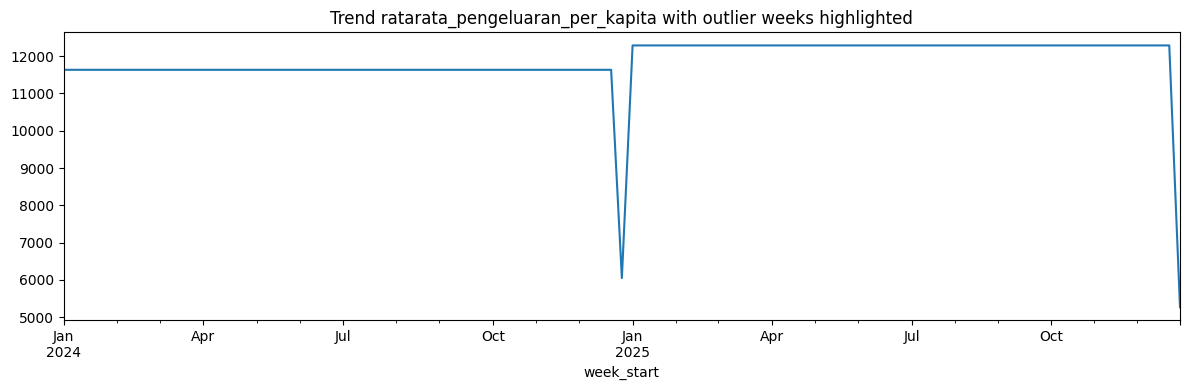

In [77]:
import matplotlib.pyplot as plt

ts = dfw.groupby(WS)[VAL].mean()
out_ts = dfw[dfw["is_outlier"]].groupby(WS)[VAL].mean()

ax = ts.plot(figsize=(12,4), title=f"Trend {VAL} with outlier weeks highlighted")

if not out_ts.empty:
    out_ts.plot(ax=ax, style="o")  # titik outlier weeks
else:
    print("No outlier weeks found (out_ts empty).")

plt.tight_layout()
plt.show()

In [80]:
DATE = "date"
CAT = "kategori_makanan"
VAL = "ratarata_pengeluaran_per_kapita"

dfd = df_daily.copy()
dfd[DATE] = pd.to_datetime(dfd[DATE], errors="coerce")
dfd = dfd.dropna(subset=[DATE]).sort_values(DATE)

dfd["is_outlier"] = flag_outlier_iqr(dfd[VAL], k=1.5)

print("Outlier rate %:", round(dfd["is_outlier"].mean()*100, 2))
print(dfd[dfd["is_outlier"]][[DATE, CAT, VAL]].head(20))

Outlier rate %: 16.67
           date           kategori_makanan  ratarata_pengeluaran_per_kapita
1484 2024-01-01  Jumlah makanan/Total food                      254347.4098
1485 2024-01-02  Jumlah makanan/Total food                      254347.4098
1486 2024-01-03  Jumlah makanan/Total food                      254347.4098
1487 2024-01-04  Jumlah makanan/Total food                      254347.4098
1488 2024-01-05  Jumlah makanan/Total food                      254347.4098
1489 2024-01-06  Jumlah makanan/Total food                      254347.4098
1490 2024-01-07  Jumlah makanan/Total food                      254347.4098
1491 2024-01-08  Jumlah makanan/Total food                      254347.4098
1492 2024-01-09  Jumlah makanan/Total food                      254347.4098
1493 2024-01-10  Jumlah makanan/Total food                      254347.4098
1494 2024-01-11  Jumlah makanan/Total food                      254347.4098
1495 2024-01-12  Jumlah makanan/Total food                      25

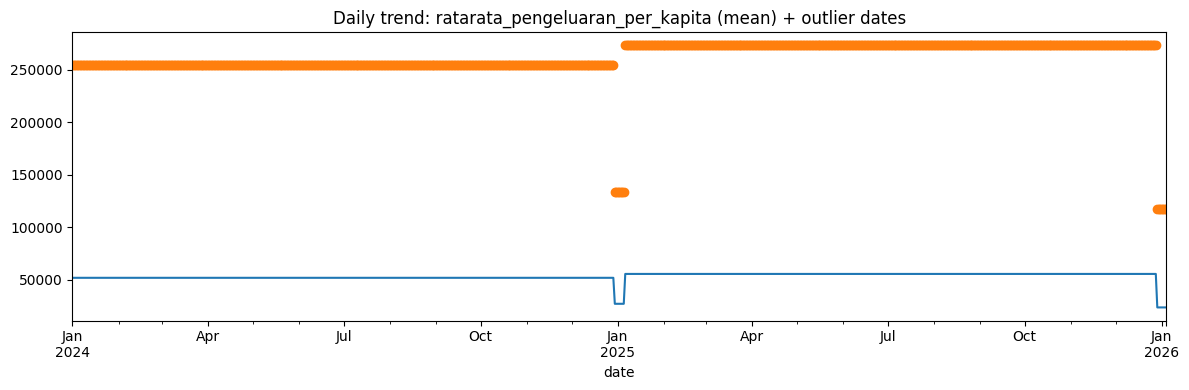

In [ ]:
# 1) Trend VAL (daily mean) + highlight tanggal outlier
# =========================
ts = dfd.groupby(DATE)[VAL].mean()
out_ts = dfd[dfd["is_outlier"]].groupby(DATE)[VAL].mean()

ax = ts.plot(figsize=(12,4), title=f"Daily trend: {VAL} (mean) + outlier dates")
if not out_ts.empty:
    out_ts.plot(ax=ax, style="o") 
else:
    print("No outlier dates found (out_ts empty).")

plt.tight_layout()
plt.show()

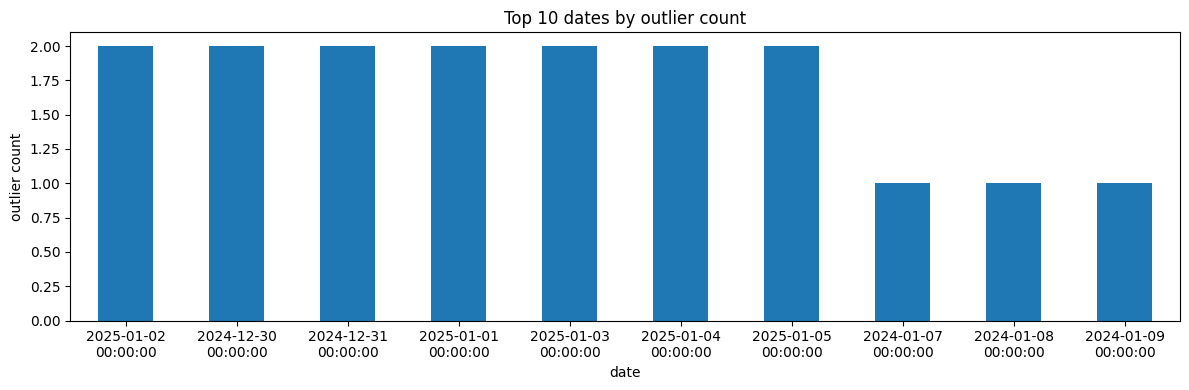

In [ ]:
def wrap(s, width=40):
    return "\n".join(textwrap.wrap(str(s), width=width))

out_count = dfd.groupby(DATE)["is_outlier"].sum().sort_values(ascending=False)

top10 = out_count.head(10)
ax = top10.plot(kind="bar", figsize=(12,4))
ax.set_title(wrap("Top 10 dates by outlier count", 40))
ax.set_ylabel(wrap("outlier count", 20))

xt = [wrap(t.get_text(), 10) for t in ax.get_xticklabels()]
ax.set_xticklabels(xt, rotation=0)

plt.tight_layout()
plt.show()

<Figure size 1200x400 with 0 Axes>

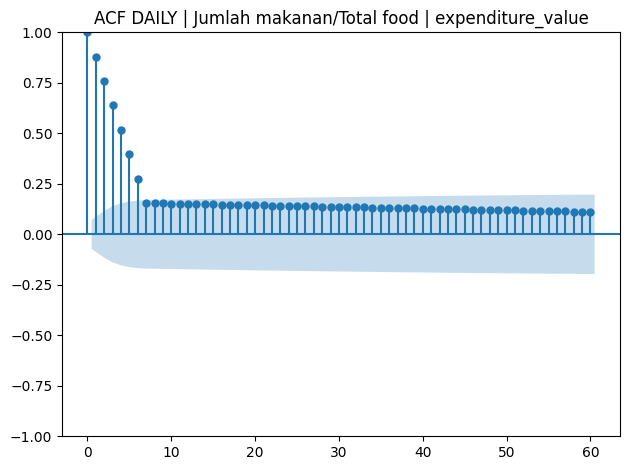

Duplicate dates after grouping: 0
Missing days introduced by asfreq: 0


In [91]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

DAILY_PATH  = "expenditure_daily_stepwise.csv"

VAL = "expenditure_value"      
CAT = "Jumlah makanan/Total food"  

dfd = pd.read_csv(DAILY_PATH)
dfd["date_dt"] = pd.to_datetime(dfd["date"], dayfirst=True, errors="coerce")

gdf = dfd.loc[(dfd["kategori_makanan"] == CAT) & dfd["date_dt"].notna(), ["date_dt", VAL]]

gdf = gdf.groupby("date_dt", as_index=False)[VAL].mean()   

g = (gdf.sort_values("date_dt")
         .set_index("date_dt")[VAL]
         .asfreq("D"))   # sekarang aman

plt.figure(figsize=(12,4))
plot_acf(g.dropna(), lags=60)
plt.title(f"ACF DAILY | {CAT} | {VAL}")
plt.tight_layout()
plt.show()

print("Duplicate dates after grouping:", g.index.duplicated().sum())
print("Missing days introduced by asfreq:", g.isna().sum())

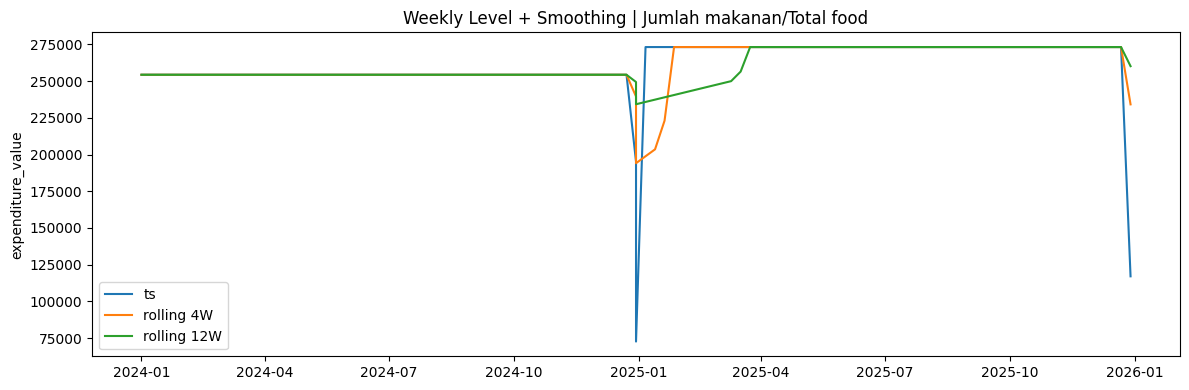

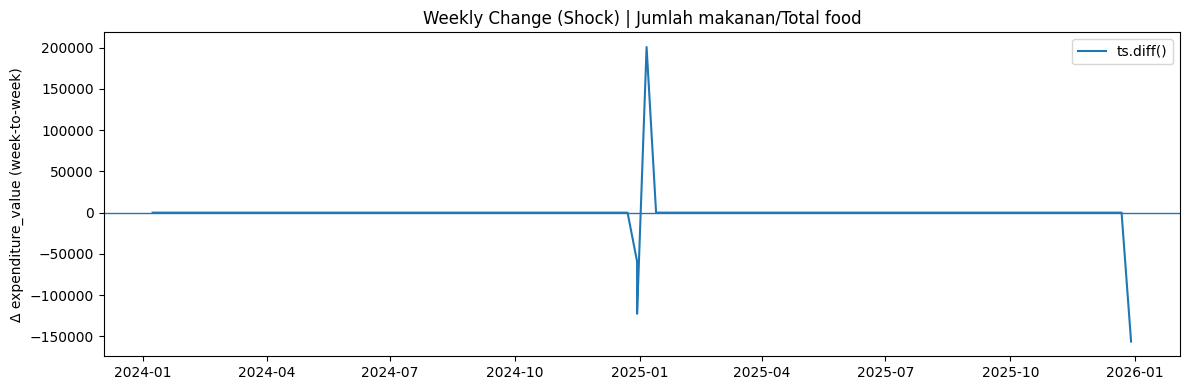

In [92]:
import pandas as pd
import matplotlib.pyplot as plt

WEEKLY_PATH = "expenditure_weekly_clean.csv"
VAL = "expenditure_value"
CAT = "Jumlah makanan/Total food"

dfw = pd.read_csv(WEEKLY_PATH)

# parse week_start (format dd/mm/yyyy)
dfw["ws_dt"] = pd.to_datetime(dfw["week_start"], dayfirst=True, errors="coerce")

# ambil 1 kategori → time series weekly
ts = (dfw[dfw["kategori_makanan"] == CAT]
      .dropna(subset=["ws_dt"])
      .sort_values("ws_dt")
      .set_index("ws_dt")[VAL])

# smoothing (rolling)
roll4 = ts.rolling(4, min_periods=1).mean()     # ~1 bulan (4 minggu)
roll12 = ts.rolling(12, min_periods=1).mean()   # ~3 bulan (12 minggu)

# change (diff): shock per minggu
d1 = ts.diff()

# --- plot level + smoothing
plt.figure(figsize=(12,4))
plt.plot(ts.index, ts.values, label="ts")
plt.plot(roll4.index, roll4.values, label="rolling 4W")
plt.plot(roll12.index, roll12.values, label="rolling 12W")
plt.title(f"Weekly Level + Smoothing | {CAT}")
plt.ylabel(VAL)
plt.legend()
plt.tight_layout()
plt.show()

# --- plot change
plt.figure(figsize=(12,4))
plt.plot(d1.index, d1.values, label="ts.diff()")
plt.axhline(0, linewidth=1)
plt.title(f"Weekly Change (Shock) | {CAT}")
plt.ylabel(f"Δ {VAL} (week-to-week)")
plt.legend()
plt.tight_layout()
plt.show()

dup week_start BEFORE: 1
dup week_start AFTER: 0


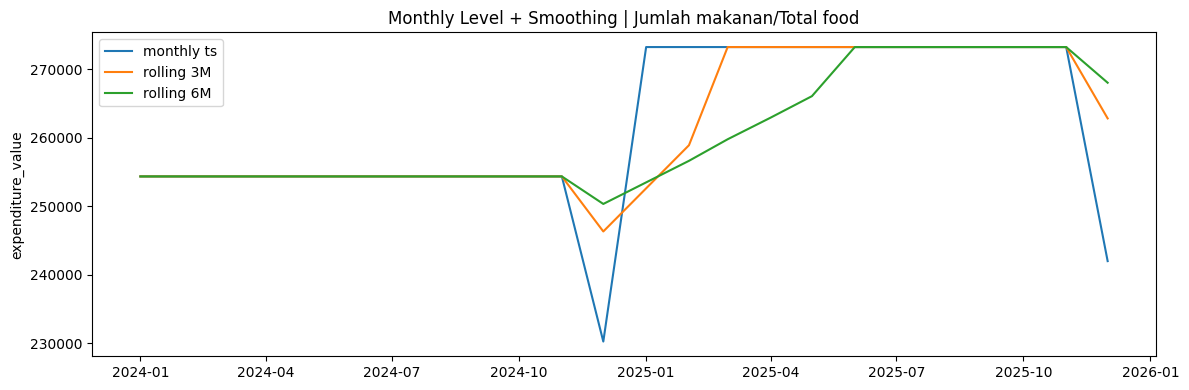

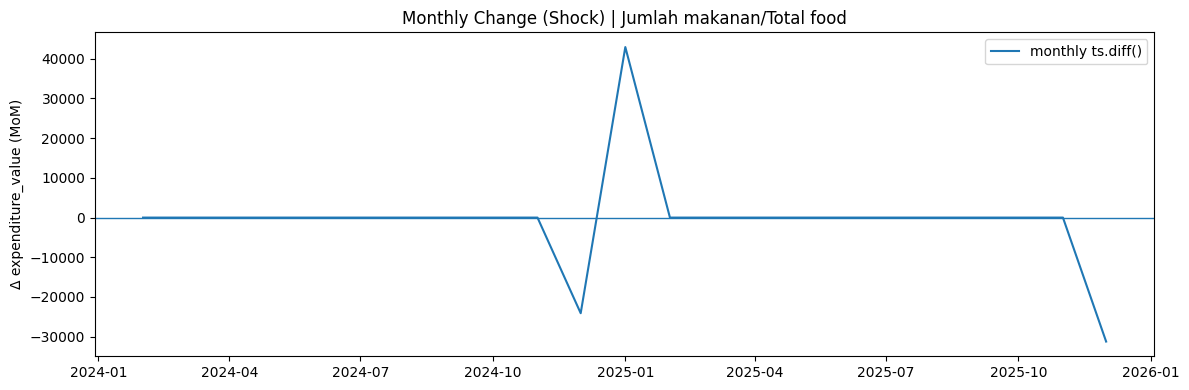

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

WEEKLY_PATH = "expenditure_weekly_clean.csv"
VAL = "expenditure_value"
CAT = "Jumlah makanan/Total food"

dfw = pd.read_csv(WEEKLY_PATH)
dfw["ws_dt"] = pd.to_datetime(dfw["week_start"], dayfirst=True, errors="coerce")

# 1) Filter kategori + buang ws_dt NaT
wdf = dfw.loc[(dfw["kategori_makanan"] == CAT) & dfw["ws_dt"].notna(), ["ws_dt", VAL]]

# 2) Diagnose + FIX duplicate week_start (pilih mean/sum)
print("dup week_start BEFORE:", wdf["ws_dt"].duplicated().sum())

weekly = (wdf.groupby("ws_dt")[VAL].mean()     # ganti .sum() kalau perlu
            .sort_index())

print("dup week_start AFTER:", weekly.index.duplicated().sum())

# 3) MONTHLY series dari weekly (tanpa asfreq)
ts_m = weekly.resample("MS").mean()

# 4) Smoothing + change
roll3 = ts_m.rolling(3, min_periods=1).mean()
roll6 = ts_m.rolling(6, min_periods=1).mean()
d1m = ts_m.diff()

# --- plot level + smoothing
plt.figure(figsize=(12,4))
plt.plot(ts_m.index, ts_m.values, label="monthly ts")
plt.plot(roll3.index, roll3.values, label="rolling 3M")
plt.plot(roll6.index, roll6.values, label="rolling 6M")
plt.title(f"Monthly Level + Smoothing | {CAT}")
plt.ylabel(VAL)
plt.legend()
plt.tight_layout()
plt.show()

# --- plot change (shock)
plt.figure(figsize=(12,4))
plt.plot(d1m.index, d1m.values, label="monthly ts.diff()")
plt.axhline(0, linewidth=1)
plt.title(f"Monthly Change (Shock) | {CAT}")
plt.ylabel(f"Δ {VAL} (MoM)")
plt.legend()
plt.tight_layout()
plt.show()

In [95]:
import pandas as pd
import numpy as np

PATH = "expenditure_weekly_clean.csv" 
df = pd.read_csv(PATH)

num = df.select_dtypes(include="number")
corr = num.corr(method="pearson")

corr

,tahun,ratarata_pengeluaran_per_kapita,iqr_low,iqr_high,expenditure_value
tahun,1.000000e+00,0.018712,8.695415e-14,8.460110e-14,0.018712
ratarata_pengeluaran_per_kapita,1.871216e-02,1.000000,9.934663e-01,9.934980e-01,1.000000
iqr_low,8.695415e-14,0.993466,1.000000e+00,9.997781e-01,0.993466
iqr_high,8.460110e-14,0.993498,9.997781e-01,1.000000e+00,0.993498
expenditure_value,1.871216e-02,1.000000,9.934663e-01,9.934980e-01,1.000000


In [96]:
import numpy as np

c = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

top_pairs = (
    c.stack()
     .abs()
     .sort_values(ascending=False)
     .head(15)
)

top_pairs

ratarata_pengeluaran_per_kapita  expenditure_value                  1.000000e+00
iqr_low                          iqr_high                           9.997781e-01
ratarata_pengeluaran_per_kapita  iqr_high                           9.934980e-01
iqr_high                         expenditure_value                  9.934980e-01
ratarata_pengeluaran_per_kapita  iqr_low                            9.934663e-01
iqr_low                          expenditure_value                  9.934663e-01
tahun                            expenditure_value                  1.871216e-02
                                 ratarata_pengeluaran_per_kapita    1.871216e-02
                                 iqr_low                            8.695415e-14
                                 iqr_high                           8.460110e-14
dtype: float64

In [97]:
import pandas as pd

VAL = "expenditure_value"
CAT = "kategori_makanan"

df = pd.read_csv("expenditure_weekly_clean.csv")

mean_by_cat = (df.groupby(CAT)[VAL]
                 .mean()
                 .sort_values(ascending=False))

mean_by_cat

kategori_makanan
Jumlah makanan/Total food                    259859.376821
Padi-padian/Cereals                           19087.642562
Daging/Meat                                   17464.792798
Telur dan susu/Eggs and milk                  14166.609746
Konsumsi lainnya/Miscellaneous food items      4136.047693
Bumbu-bumbuan/Spices                           4055.378711
Name: expenditure_value, dtype: float64

In [98]:
import pandas as pd

VAL = "expenditure_value"
CAT = "kategori_makanan"

df = pd.read_csv("expenditure_weekly_clean.csv")

mean_by_cat = (df.groupby(CAT)[VAL]
                 .mean()
                 .sort_values(ascending=False))

mean_by_cat

kategori_makanan
Jumlah makanan/Total food                    259859.376821
Padi-padian/Cereals                           19087.642562
Daging/Meat                                   17464.792798
Telur dan susu/Eggs and milk                  14166.609746
Konsumsi lainnya/Miscellaneous food items      4136.047693
Bumbu-bumbuan/Spices                           4055.378711
Name: expenditure_value, dtype: float64

In [99]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

WEEKLY_PATH = "expenditure_weekly_clean.csv"
DAILY_PATH  = "expenditure_daily_stepwise.csv"

OUTDIR = "eda_outputs"
os.makedirs(OUTDIR, exist_ok=True)

# -----------------------------
# Helpers
# -----------------------------
def wrap_xticks(ax, rotation=45):
    for t in ax.get_xticklabels():
        t.set_rotation(rotation)
        t.set_ha("right")

def summary_table(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Summary standar: missing, duplicates, min/max, quantiles utk numeric."""
    out = []

    # duplicate rows keseluruhan
    dup_rows = df.duplicated().sum()

    # per kolom
    for c in df.columns:
        s = df[c]
        row = {
            "dataset": name,
            "column": c,
            "dtype": str(s.dtype),
            "missing_n": int(s.isna().sum()),
            "missing_pct": float(s.isna().mean()),
            "n_unique": int(s.nunique(dropna=True)),
        }
        if pd.api.types.is_numeric_dtype(s):
            qs = s.dropna().quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1]).to_dict()
            row.update({
                "min": qs.get(0.0, np.nan),
                "q01": qs.get(0.01, np.nan),
                "q05": qs.get(0.05, np.nan),
                "q25": qs.get(0.25, np.nan),
                "median": qs.get(0.5, np.nan),
                "q75": qs.get(0.75, np.nan),
                "q95": qs.get(0.95, np.nan),
                "q99": qs.get(0.99, np.nan),
                "max": qs.get(1.0, np.nan),
            })
        out.append(row)

    meta = pd.DataFrame([{
        "dataset": name,
        "column": "__DATASET_LEVEL__",
        "dtype": "",
        "missing_n": "",
        "missing_pct": "",
        "n_unique": "",
        "min": "",
        "q01": "",
        "q05": "",
        "q25": "",
        "median": "",
        "q75": "",
        "q95": "",
        "q99": "",
        "max": "",
        "dup_rows_total": int(dup_rows),
        "n_rows": int(len(df)),
        "n_cols": int(df.shape[1]),
    }])
    return pd.concat([meta, pd.DataFrame(out)], ignore_index=True)


In [101]:
def summary_table(df: pd.DataFrame, name: str) -> pd.DataFrame:
    out = []
    dup_rows = int(df.duplicated().sum())

    for c in df.columns:
        s = df[c]
        row = {
            "dataset": name,
            "column": c,
            "dtype": str(s.dtype),
            "missing_n": int(s.isna().sum()),
            "missing_pct": float(s.isna().mean()),
            "n_unique": int(s.nunique(dropna=True)),
        }

        # Skip boolean columns (quantile untuk bool bikin error/ga meaningful)
        if pd.api.types.is_bool_dtype(s):
            out.append(row)
            continue

        # Coba paksa numeric (buat handle object yang isinya angka campur string)
        sn = pd.to_numeric(s, errors="coerce")

        # Anggap numeric valid kalau ada minimal 2 nilai numeric non-NaN
        if sn.notna().sum() >= 2:
            qs = sn.dropna().quantile([0, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1]).to_dict()
            row.update({
                "min": qs.get(0.0, np.nan),
                "q01": qs.get(0.01, np.nan),
                "q05": qs.get(0.05, np.nan),
                "q25": qs.get(0.25, np.nan),
                "median": qs.get(0.5, np.nan),
                "q75": qs.get(0.75, np.nan),
                "q95": qs.get(0.95, np.nan),
                "q99": qs.get(0.99, np.nan),
                "max": qs.get(1.0, np.nan),
            })

        out.append(row)

    meta = pd.DataFrame([{
        "dataset": name,
        "column": "__DATASET_LEVEL__",
        "dtype": "",
        "missing_n": "",
        "missing_pct": "",
        "n_unique": "",
        "min": "",
        "q01": "",
        "q05": "",
        "q25": "",
        "median": "",
        "q75": "",
        "q95": "",
        "q99": "",
        "max": "",
        "dup_rows_total": dup_rows,
        "n_rows": int(len(df)),
        "n_cols": int(df.shape[1]),
    }])

    return pd.concat([meta, pd.DataFrame(out)], ignore_index=True)

In [102]:
# Load + parse dates
# -----------------------------
dfw = pd.read_csv(WEEKLY_PATH)
dfd = pd.read_csv(DAILY_PATH)

# weekly parse
dfw["ws_dt"] = pd.to_datetime(dfw.get("week_start"), dayfirst=True, errors="coerce")
dfw["we_dt"] = pd.to_datetime(dfw.get("week_end"), dayfirst=True, errors="coerce")

# daily parse
dfd["date_dt"] = pd.to_datetime(dfd.get("date"), dayfirst=True, errors="coerce")

# -----------------------------
# Save summary tables
# -----------------------------
sum_w = summary_table(dfw, "weekly")
sum_d = summary_table(dfd, "daily")

sum_w.to_csv(os.path.join(OUTDIR, "summary_weekly.csv"), index=False)
sum_d.to_csv(os.path.join(OUTDIR, "summary_daily.csv"), index=False)


In [104]:
anom_rows = []

# NaT rows weekly
nat_w = dfw[dfw["ws_dt"].isna() | dfw["we_dt"].isna()].copy()
nat_w["anomaly_type"] = "NaT_week_start_or_end"
anom_rows.append(nat_w)

# week length anomaly
wk = dfw[dfw["ws_dt"].notna() & dfw["we_dt"].notna()].copy()
wk["week_len_days"] = (wk["we_dt"] - wk["ws_dt"]).dt.days + 1  # inclusive
wk_len_bad = wk[wk["week_len_days"] != 7].copy()
wk_len_bad["anomaly_type"] = "week_len_days!=7"
anom_rows.append(wk_len_bad)

# gap days anomaly (per kategori_makanan, pakai ws_dt)
if "kategori_makanan" in dfw.columns:
    g = dfw[dfw["ws_dt"].notna()].copy()
    g = g.sort_values(["kategori_makanan", "ws_dt"])
    g["gap_days"] = g.groupby("kategori_makanan")["ws_dt"].diff().dt.days
    gap_bad = g[g["gap_days"].notna() & (g["gap_days"] != 7)].copy()
    gap_bad["anomaly_type"] = "gap_days!=7"
    anom_rows.append(gap_bad)

# NaT rows daily
nat_d = dfd[dfd["date_dt"].isna()].copy()
nat_d["anomaly_type"] = "NaT_date"
anom_rows.append(nat_d)

anom = pd.concat(anom_rows, ignore_index=True) if anom_rows else pd.DataFrame()
anom.to_csv(os.path.join(OUTDIR, "anomalies.csv"), index=False)

In [105]:
VAL = "expenditure_value"
CAT = "kategori_makanan"

# Trend total (weekly) = sum across kategori per week_start
if "ws_dt" in dfw.columns and VAL in dfw.columns:
    w_ok = dfw[dfw["ws_dt"].notna()].copy()
    total_w = w_ok.groupby("ws_dt")[VAL].sum().sort_index()

    plt.figure(figsize=(12,4))
    plt.plot(total_w.index, total_w.values)
    plt.title("Trend total (weekly) — sum across categories")
    plt.ylabel(VAL)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "trend_total_weekly.png"), dpi=180)
    plt.close()

# Trend per kategori top 5 (weekly) — EXCLUDE "Jumlah makanan/Total food"
if "ws_dt" in dfw.columns and CAT in dfw.columns and VAL in dfw.columns:
    w_ok = dfw[dfw["ws_dt"].notna()].copy()

    EXCLUDE = {"Jumlah makanan/Total food"}  # kalau ada variasi nama, tambahin di sini

    w_sub = w_ok[~w_ok[CAT].isin(EXCLUDE)].copy()

    # top5 kategori by mean value 
    top5 = (w_sub.groupby(CAT)[VAL]
                 .mean()
                 .sort_values(ascending=False)
                 .head(5)
                 .index
                 .tolist())

    plt.figure(figsize=(12,5))
    for k in top5:
        s = (w_sub[w_sub[CAT] == k].groupby("ws_dt")[VAL].mean().sort_index())
        plt.plot(s.index, s.values, label=k)
    plt.title("Trend per kategori — Top 5 by mean (weekly) [exclude Total food]")
    plt.ylabel(VAL)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "trend_top5_categories_weekly.png"), dpi=180)
    plt.close()

# 4b) Trend per kategori top 5 (weekly) — EXCLUDE "Jumlah makanan/Total food"
if "ws_dt" in dfw.columns and CAT in dfw.columns and VAL in dfw.columns:
    w_ok = dfw[dfw["ws_dt"].notna()].copy()

    EXCLUDE = {"Jumlah makanan/Total food"}  # kalau ada variasi nama, tambahin di sini

    w_sub = w_ok[~w_ok[CAT].isin(EXCLUDE)].copy()

    # top5 kategori by mean value (setelah exclude)
    top5 = (w_sub.groupby(CAT)[VAL]
                 .mean()
                 .sort_values(ascending=False)
                 .head(5)
                 .index
                 .tolist())

    plt.figure(figsize=(12,5))
    for k in top5:
        s = (w_sub[w_sub[CAT] == k].groupby("ws_dt")[VAL].mean().sort_index())
        plt.plot(s.index, s.values, label=k)
    plt.title("Trend per kategori — Top 5 by mean (weekly) [exclude Total food]")
    plt.ylabel(VAL)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "trend_top5_categories_weekly.png"), dpi=180)
    plt.close()

# 4c) Heatmap dow-month (daily): mean(VAL) by weekday x month

if "date_dt" in dfd.columns and VAL in dfd.columns:
    d_ok = dfd[dfd["date_dt"].notna()].copy()
    d_ok["dow"] = d_ok["date_dt"].dt.day_name()   # Monday..Sunday (English)
    d_ok["month"] = d_ok["date_dt"].dt.to_period("M").astype(str)

    # kalau ada kategori, pakai total dulu (sum across kategori per day) biar heatmap single
    if CAT in dfd.columns:
        daily_total = d_ok.groupby(["date_dt"])[VAL].sum().reset_index()
        daily_total["dow"] = daily_total["date_dt"].dt.day_name()
        daily_total["month"] = daily_total["date_dt"].dt.to_period("M").astype(str)

        piv = daily_total.pivot_table(index="dow", columns="month", values=VAL, aggfunc="mean")
    else:
        piv = d_ok.pivot_table(index="dow", columns="month", values=VAL, aggfunc="mean")

    # order weekday
    order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
    piv = piv.reindex(order)

    # plot heatmap via imshow
    fig, ax = plt.subplots(figsize=(14,4))
    im = ax.imshow(piv.values, aspect="auto")
    ax.set_title("Heatmap (daily) — mean value by day-of-week x month")
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns)
    wrap_xticks(ax, rotation=60)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTDIR, "heatmap_dow_month_daily.png"), dpi=180)
    plt.close()


In [106]:
print(f"✅ EDA outputs saved to: {OUTDIR}/")
print(" - summary_weekly.csv, summary_daily.csv")
print(" - anomalies.csv")
print(" - trend_total_weekly.png")
print(" - trend_top5_categories_weekly.png")
print(" - heatmap_dow_month_daily.png")

✅ EDA outputs saved to: eda_outputs/
 - summary_weekly.csv, summary_daily.csv
 - anomalies.csv
 - trend_total_weekly.png
 - trend_top5_categories_weekly.png
 - heatmap_dow_month_daily.png
